# Lab 5/6 — The GPU submission protocol, measured

> **Lab thesis:** there is no *call the GPU* instruction. Every kernel launch is a command appended to a queue, one doorbell write, and a fence that comes back later. In this lab you measure that protocol from the outside — and watch it manufacture a throughput number that beats the hardware.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ankush-Chander/DS635-ml-system-engineering/blob/main/docs/labs/Lab5_6_gpu_job_submission.ipynb)

This lab is the experimental half of [Lecture 5/6 — GPU Job Submission](../lectures/Lecture5_6.md). The lecture derived the mechanism. Here you observe its consequences. The marking scheme, submission rules and integrity policy are on the [lab brief](Lab5_6.md).

## Where this runs

**NVIDIA (CUDA)**, **AMD (ROCm)** and **Apple silicon (MPS)** are all supported. On Google Colab, pick `Runtime > Change runtime type > T4 GPU`.

`torch.cuda` is the correct namespace on ROCm — that is not a typo. Apple's Metal backend exposes no command streams and no graph capture, so two experiments are skipped there automatically; the export records what was skipped and **you are not penalised for it**.

## How to work through it

Every part follows the same three steps, and **the order matters**:

1. **Predict** — write your prediction in the cell provided *before* running anything. A wrong prediction you then explain is worth full marks. A blank prediction is not.
2. **Measure** — run the cell. Do not edit the timing harness unless a task tells you to.
3. **Explain** — say *which mechanism from the lecture* produced the number. "It's faster because pinned memory is faster" is not an explanation; naming the staging copy is.

Numbers will differ from any shown here. **You are graded on the reasoning, not on matching a reference number.** An honest surprising result, correctly explained, scores higher than a tidy expected one.

## What to submit

1. `submission_<roll>.json` — written by the final cell.
2. This notebook, executed, with every 📝 cell filled in.

**Total: 100 marks** — 40 automatic, 60 rubric.

---
## Part 0 — Setup and machine identification *(5 marks)*

Establish what you are measuring on. Every number in your report is meaningless without it.

In [15]:
# ---------------------------------------------------------------------------
# One backend abstraction for the whole lab.
# CUDA (NVIDIA), HIP (AMD/ROCm) and MPS (Apple silicon) are all supported.
# `torch.cuda` is the correct namespace on ROCm -- that is not a typo.
# ---------------------------------------------------------------------------
import json, time, platform, subprocess
from datetime import datetime, timezone

import torch
import matplotlib.pyplot as plt


def _detect():
    if torch.cuda.is_available():
        return "cuda", ("rocm" if torch.version.hip else "cuda")
    mps = getattr(torch.backends, "mps", None)
    if mps is not None and mps.is_available():
        return "mps", "mps"
    return None, None

DEV, VENDOR = _detect()
assert DEV, (
    "No GPU visible to PyTorch.\n"
    "  Colab : Runtime > Change runtime type > T4 GPU\n"
    "  NVIDIA: check `nvidia-smi`\n"
    "  AMD   : check `rocm-smi`\n"
    "  Apple : needs an arm64 build of PyTorch on macOS 12.3+"
)

_mod = torch.cuda if DEV == "cuda" else torch.mps

def sync():
    _mod.synchronize()

def empty_cache():
    try: _mod.empty_cache()
    except Exception: pass

def _events():
    """(start, end) timing events, or (None, None) if unsupported."""
    try:
        E = torch.cuda.Event if DEV == "cuda" else torch.mps.Event
        return E(enable_timing=True), E(enable_timing=True)
    except Exception:
        return None, None

def _pinning_works():
    if DEV != "cuda":
        return False
    try:
        torch.empty(8, dtype=torch.float32, pin_memory=True)
        return True
    except Exception:
        return False

CAPS = {
    "events":  _events()[0] is not None,
    "pinned":  _pinning_works(),
    "streams": DEV == "cuda",                     # no public MPS stream API
    "graphs":  DEV == "cuda" and hasattr(torch.cuda, "CUDAGraph"),
}

if DEV == "cuda":
    _p = torch.cuda.get_device_properties(0)
    DEVICE = _p.name
    BACKEND = f"ROCm/HIP {torch.version.hip}" if VENDOR == "rocm" else f"CUDA {torch.version.cuda}"
    VRAM_GB = round(_p.total_memory / 1e9, 2)
    MP_COUNT = _p.multi_processor_count
    ARCH = getattr(_p, "gcnArchName", None) or "sm_%d%d" % torch.cuda.get_device_capability(0)
    CLOCK_GHZ = round(getattr(_p, "clock_rate", 0) / 1e6, 3) or None
else:
    DEVICE = f"Apple silicon GPU ({platform.machine()})"
    BACKEND = "Metal / MPS"
    try:
        VRAM_GB = round(torch.mps.recommended_max_memory() / 1e9, 2)
    except Exception:
        VRAM_GB = None
    MP_COUNT = None          # not exposed by Metal through PyTorch
    ARCH = platform.processor() or "apple"
    CLOCK_GHZ = None

print(f"device   : {DEVICE}")
print(f"backend  : torch {torch.__version__}  ({BACKEND})")
print(f"VRAM     : {VRAM_GB} GB" if VRAM_GB else "VRAM     : (unified memory)")
print(f"arch     : {ARCH}")
print(f"capabilities: " + ", ".join(f"{k}={'yes' if v else 'NO'}" for k, v in CAPS.items()))
if not all(CAPS.values()):
    print("\\nSome experiments will be skipped on this backend. That is expected and")
    print("is not penalised -- the export records what was skipped and why.")

# ------------------------------------------------------------------
# IDENTIFY YOURSELF -- the export file is named from this.
ROLL_NUMBER = "202518044"      # <-- EDIT ME, e.g. "202301234"
NAME        = "Neel Shah"      # <-- EDIT ME
# ------------------------------------------------------------------

RESULTS = {"schema_version": 2, "env": {}, "results": {}, "answers": {}}
RESULTS["env"] = {
    "device": DEVICE, "vendor": VENDOR, "backend": BACKEND, "torch": torch.__version__,
    "vram_gb": VRAM_GB, "multi_processor_count": MP_COUNT, "arch": str(ARCH),
    "clock_ghz_reported": CLOCK_GHZ, "caps": CAPS,
    "platform": platform.platform(),
    "started_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
}
if not ROLL_NUMBER:
    print("\\n>>> Set ROLL_NUMBER and NAME above before exporting. <<<")

device   : Tesla T4
backend  : torch 2.11.0+cu128  (CUDA 12.8)
VRAM     : 15.64 GB
arch     : Tesla T4
capabilities: events=yes, pinned=yes, streams=yes, graphs=yes


### ⚡ Preflight — power, before you run anything heavy

This lab deliberately drives the GPU to **sustained peak power** for seconds at a time. That is the point: a large fp32 matmul run back-to-back is close to the worst-case power draw the chip can produce.

On a **laptop running on battery** that is a genuine hazard. A discrete mobile GPU can be permitted to draw more than the battery and VRM can deliver under a sustained load, and the machine then **hard-resets with nothing written to the logs** — no kernel panic, no GPU reset message, just an instant reboot. It is not a crash you can debug from Python, because Python was never the problem.

The cell below checks your power source and scales the workload down automatically if you are not on mains.

In [16]:
import glob, os

def on_ac_power():
    """True on mains, False on battery, None if undetectable (Colab, some VMs)."""
    found = False
    for online in glob.glob("/sys/class/power_supply/*/online"):
        try:
            kind = open(os.path.join(os.path.dirname(online), "type")).read().strip()
            if kind != "Mains":
                continue
            found = True
            if open(online).read().strip() == "1":
                return True
        except OSError:
            continue
    if found:
        return False
    if platform.system() == "Darwin":          # macOS: ask pmset
        try:
            out = subprocess.run(["pmset", "-g", "batt"], capture_output=True,
                                 text=True, timeout=5).stdout
            if "AC Power" in out:
                return True
            if "Battery Power" in out:
                return False
        except Exception:
            pass
    return None

AC = on_ac_power()
SAFE_MODE = (AC is False)

if AC is None:
    print("power source : not detectable (cloud/VM - fine, nothing to worry about)")
elif AC:
    print("power source : AC / mains  OK")
else:
    print("power source : BATTERY  !!")
    print("               A sustained peak-power GPU load on battery can brown out")
    print("               the machine and reboot it instantly, with no logs.")
    print("               >>> Plug in the charger and re-run this cell. <<<")

MATMUL_N   = 2048 if SAFE_MODE else 4096
ITERS      = 10   if SAFE_MODE else 30
SWEEP_MAX  = 2**22 if SAFE_MODE else 2**24
SIZES_MB   = [1, 4, 16, 64] if SAFE_MODE else [1, 4, 16, 64, 256]
OVERLAP_MB = 64 if SAFE_MODE else 128

def cooldown(seconds=2.0):
    """Let the GPU drop out of a boost state between heavy cells."""
    sync()
    time.sleep(seconds)

print(f"\nSAFE_MODE    : {SAFE_MODE}")
print(f"matmul N     : {MATMUL_N}   iterations: {ITERS}")
print(f"transfers    : {SIZES_MB} MB")

RESULTS["env"].update({"ac_power": AC, "safe_mode": SAFE_MODE,
                       "matmul_n": MATMUL_N, "iters": ITERS})

power source : not detectable (cloud/VM - fine, nothing to worry about)

SAFE_MODE    : False
matmul N     : 4096   iterations: 30
transfers    : [1, 4, 16, 64, 256] MB


> **If your machine rebooted while running this lab**, that is a hardware/power event rather than a bug in this notebook. Plug in mains power, keep `SAFE_MODE = True`, and on Linux check `journalctl -b -1 -k | tail -50`. A reboot leaving **no** kernel message at all is a power event; one preceded by a `ring … timeout` or `GPU reset` message is a driver hang, which is a different problem.

### The two stopwatches

Used for the rest of the lab. Timing events exist on CUDA, ROCm and MPS; where they do not, the harness falls back to a synchronised wall clock.

In [17]:
def gpu_time_ms(fn, iters=50, warmup=10):
    """Time on the device with timing events, falling back to a synced wall clock.

    Events are fences placed IN the command queue, so they timestamp when the
    device reached them -- not when the CPU queued them.
    """
    for _ in range(warmup):
        fn()
    sync()
    start, end = _events()
    if start is None:                      # no event API on this backend
        return wall_time_ms(fn, iters=iters, warmup=0, sync_after=True)
    start.record()
    for _ in range(iters):
        fn()
    end.record()
    sync()
    return start.elapsed_time(end) / iters


def wall_time_ms(fn, iters=50, warmup=10, sync_after=True):
    """Time with a CPU stopwatch.

    With sync_after=False this measures SUBMISSION: how long the CPU spent
    appending commands and ringing the doorbell. That is the number that lies.
    """
    for _ in range(warmup):
        fn()
    sync()
    t0 = time.perf_counter()
    for _ in range(iters):
        fn()
    if sync_after:
        sync()
    return (time.perf_counter() - t0) * 1e3 / iters


print("harness ready")

harness ready


---
## Part 1 — Establish the roof *(20 marks)*

Everything after this point is compared against one number: your GPU's **theoretical peak FP32 throughput**. Part 2 hinges on producing a measurement that *exceeds* it, so the number has to mean something.

Getting it is not straightforward, and that is the lesson. There are three routes, they disagree, and the disagreements are informative.

```text
Route A  what the hardware reports   → derive it yourself
Route B  what the vendor advertises  → look it up
Route C  what you can actually reach → measure it
```

The classic form is:

```text
peak FLOP/s  =  compute units × lanes per unit × 2 × clock
                                                 ↑
                                      one FMA = 2 FLOPs
```

Every term on the right is a trap.

### Why each term is a trap

**`compute units` — the driver tells you a count, but not what it counts.**

On this course's AMD RX 6700M, PyTorch reports `multi_processor_count = 18`. The card has **36** compute units. Neither number is wrong: RDNA groups 2 CUs into one *Work Group Processor*, and that is what gets reported. Derive peak from 18 × 64 lanes and you get exactly **half** the right answer.

NVIDIA reports SMs, and lanes-per-SM depends on the architecture: 64 on Volta/Turing/A100, 128 on Ampere GA10x, Ada and Hopper. `torch.cuda.get_device_capability()` gives you the compute capability to look it up — except on ROCm, where the same call returns `(10, 3)` meaning *gfx1030*, not compute capability 10.3.

**`lanes per unit`** is therefore not queryable in any portable way. You have to know your architecture.

**`clock`** — base or boost? Sustained or burst? `clock_rate` in the device properties is usually the boost ceiling, which the chip may not hold under a sustained matmul, especially on a laptop.

**`× 2`** is the fused multiply-add counting as two operations. Fine — but vendors sometimes apply *further* multipliers you must not copy blindly:

| Marketing multiplier | What it really means |
|---|---|
| Tensor / matrix core TFLOPS | a different datapath, usually not FP32 |
| "with sparsity" | 2× assuming a 2:1 structured-sparse model |
| TF32 / BF16 / FP8 numbers | lower precision, not the FP32 roof |
| RDNA3 "dual-issue" FP32 | only reachable by specific instruction patterns |

A spec sheet's headline number is frequently the largest of these. **You want the plain FP32 vector roof.**

**On Apple silicon** none of this is exposed at all. Metal reports no core count, no clock, and Apple publishes no official FP32 FLOPS. Route A is unavailable; you rely on Routes B and C, and say so.

### Route A — derive it from what the hardware reports

The cell below gathers every term it can and tells you which ones it cannot. Where it cannot, **you** supply the value.

In [18]:
# NVIDIA FP32 lanes per SM, by compute capability. There is no API for this.
NV_LANES_PER_SM = {
    (3, 0): 192, (3, 5): 192, (3, 7): 192,
    (5, 0): 128, (5, 2): 128, (5, 3): 128,
    (6, 0): 64,  (6, 1): 128, (6, 2): 128,
    (7, 0): 64,  (7, 2): 64,  (7, 5): 64,
    (8, 0): 64,  (8, 6): 128, (8, 7): 128, (8, 9): 128,
    (9, 0): 128, (10, 0): 128, (12, 0): 128,
}

lanes_per_unit, unit_name, note = None, "unit", ""

if VENDOR == "cuda":
    cc = torch.cuda.get_device_capability(0)
    lanes_per_unit = NV_LANES_PER_SM.get(cc)
    unit_name = "SM"
    note = (f"compute capability {cc[0]}.{cc[1]}"
            + ("" if lanes_per_unit else " -- NOT in the table, look it up yourself"))
elif VENDOR == "rocm":
    a = str(ARCH)
    if a.startswith(("gfx10", "gfx11", "gfx12")):
        # RDNA: the reported count is WGPs, and one WGP = 2 CUs x 64 lanes.
        lanes_per_unit, unit_name = 128, "WGP (= 2 CU)"
        note = f"{a}: RDNA, reported count is WGPs not CUs -- this is the x2 trap"
    else:
        lanes_per_unit, unit_name = 64, "CU"
        note = f"{a}: GCN/CDNA, 64 FP32 lanes per CU"
else:
    note = "Metal exposes no core count or clock -- Route A is unavailable on Apple silicon"

print(f"reported units   : {MP_COUNT}   ({unit_name})")
print(f"lanes per unit   : {lanes_per_unit}")
print(f"reported clock   : {CLOCK_GHZ} GHz")
print(f"note             : {note}")

# ---- OVERRIDE these if the values above are wrong or missing. --------------
UNITS_OVERRIDE  = None    # e.g. 36 if you know the real CU count
LANES_OVERRIDE  = None    # e.g. 64
CLOCK_GHZ_OVERRIDE = None # e.g. 2.3 for the *sustained* clock
# ---------------------------------------------------------------------------

u = UNITS_OVERRIDE if UNITS_OVERRIDE is not None else MP_COUNT
l = LANES_OVERRIDE if LANES_OVERRIDE is not None else lanes_per_unit
c = CLOCK_GHZ_OVERRIDE if CLOCK_GHZ_OVERRIDE is not None else CLOCK_GHZ

if None in (u, l, c):
    PEAK_DERIVED = None
    print("\\nRoute A incomplete -- fill the overrides above, or leave it as None")
    print("and rely on Routes B and C (valid on Apple silicon; say so in your answer).")
else:
    PEAK_DERIVED = u * l * 2 * c / 1e3
    print(f"\\nRoute A: {u} x {l} lanes x 2 FLOP/FMA x {c} GHz = {PEAK_DERIVED:.2f} TFLOP/s")

reported units   : 40   (SM)
lanes per unit   : 64
reported clock   : 1.59 GHz
note             : compute capability 7.5
\nRoute A: 40 x 64 lanes x 2 FLOP/FMA x 1.59 GHz = 8.14 TFLOP/s


### Route B — what the vendor advertises

Look up your exact GPU. Good sources: the vendor's own product page, or TechPowerUp's GPU database (which lists FP32 separately from tensor-core and sparsity numbers).

Record the **plain FP32 vector** figure — not the tensor-core number, not the "with sparsity" number, not a lower-precision number.

In [19]:
# ---- FILL THIS IN ---------------------------------------------------------
PEAK_VENDOR   = 8.1   # TFLOP/s, plain FP32. e.g. 10.6
PEAK_SOURCE   = "NVIDIA Tesla T4 specifications"     # where you got it, e.g. "TechPowerUp RX 6700M"
# ---------------------------------------------------------------------------

assert PEAK_VENDOR, "Look up your GPU's FP32 peak and set PEAK_VENDOR."
print(f"Route B: {PEAK_VENDOR} TFLOP/s   (source: {PEAK_SOURCE or 'UNCITED'})")
if PEAK_DERIVED:
    d = PEAK_DERIVED / PEAK_VENDOR
    print(f"         Route A / Route B = {d:.2f}x", end="  ")
    print("-- agree" if 0.85 <= d <= 1.15 else "-- DISAGREE, explain why below")

Route B: 8.1 TFLOP/s   (source: NVIDIA Tesla T4 specifications)
         Route A / Route B = 1.01x  -- agree


### Route C — what you can actually reach

The roof is a limit, not a promise. Measure the best FP32 matmul throughput your machine will actually sustain, and take the maximum over several shapes.

In [20]:
mm_sizes = [512, 1024, 2048] if SAFE_MODE else [1024, 2048, 4096]
achieved = []

for n in mm_sizes:
    a = torch.randn(n, n, device=DEV)
    b = torch.randn(n, n, device=DEV)
    ms = gpu_time_ms(lambda: a @ b, iters=10, warmup=5)
    tf = (2 * n ** 3) / (ms * 1e-3) / 1e12
    achieved.append(tf)
    print(f"  N={n:<6} {ms:8.3f} ms   {tf:7.2f} TFLOP/s")
    del a, b
    empty_cache()

PEAK_MEASURED = max(achieved)
print(f"\\nRoute C: {PEAK_MEASURED:.2f} TFLOP/s achieved "
      f"({PEAK_MEASURED / PEAK_VENDOR * 100:.0f}% of vendor peak)")

# The roof used for the rest of the lab.
PEAK_TFLOPS = PEAK_VENDOR

RESULTS["results"]["peak"] = {
    "derived_tflops": PEAK_DERIVED,
    "derived_units": u, "derived_lanes": l, "derived_clock_ghz": c,
    "vendor_tflops": PEAK_VENDOR, "vendor_source": PEAK_SOURCE,
    "measured_tflops": PEAK_MEASURED,
    "measured_sizes": mm_sizes, "measured_tflops_all": achieved,
    "efficiency": PEAK_MEASURED / PEAK_VENDOR,
}
RESULTS["env"]["peak_tflops_declared"] = PEAK_TFLOPS

  N=1024      0.834 ms      2.58 TFLOP/s
  N=2048      6.033 ms      2.85 TFLOP/s
  N=4096     46.059 ms      2.98 TFLOP/s
\nRoute C: 2.98 TFLOP/s achieved (37% of vendor peak)


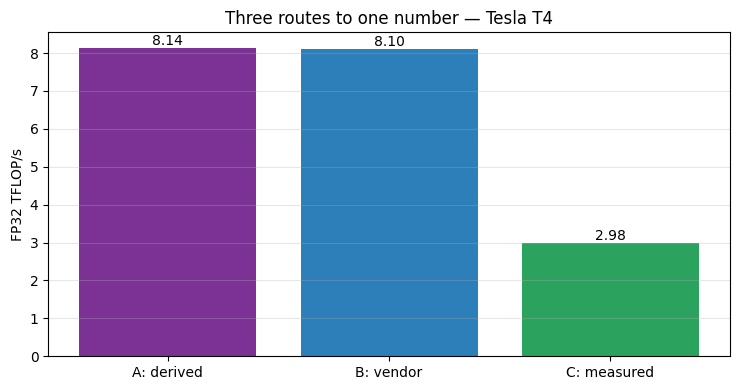

In [21]:
fig, ax = plt.subplots(figsize=(7.5, 4))
routes = [("A: derived", PEAK_DERIVED), ("B: vendor", PEAK_VENDOR), ("C: measured", PEAK_MEASURED)]
routes = [(k, v) for k, v in routes if v]
ax.bar([k for k, _ in routes], [v for _, v in routes],
       color=["#7b3294", "#2c7fb8", "#2ca25f"][:len(routes)])
for i, (_, v) in enumerate(routes):
    ax.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("FP32 TFLOP/s")
ax.set_title(f"Three routes to one number — {DEVICE}")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

📝 **Task 1.1 — reconcile the three routes** *(12 marks)*

- Report all three numbers, and the source you used for Route B.
- **Route C is below Route B.** By how much, and where did the missing throughput go? Name at least two distinct causes.
- If Route A disagreed with Route B by more than 15%, explain which term was wrong. If it agreed, say which values you had to override to make it agree — *and whether you would have caught the error had the vendor number not been there to check against*.
- If you are on Apple silicon and Route A was unavailable: what would you need Apple to publish to make it possible?

*Your answer:*

- Route A gave a derived FP32 peak of 8.14 TFLOP/s using 40 SMs, 64 FP32 lanes per SM, a factor of 2 FLOPs per FMA, and a reported clock of 1.59 GHz. Route B gives a vendor FP32 peak of 8.10 TFLOP/s for the Tesla T4. The two values agree extremely closely, with Route A being only about 0.5% higher than Route B. This indicates that the reported SM count, lane count and clock produce a reasonable theoretical FP32 roof.

Route C measured the actual sustained FP32 throughput of my GPU, which was below the vendor/theoretical peak. The missing throughput is expected because theoretical peak assumes ideal utilization. In practice, throughput is reduced by factors such as memory/data movement, instruction and scheduling overhead, imperfect GPU utilization, and the fact that the GPU may not sustain its reported peak clock during a long computation.

Route A did not disagree with Route B by more than 15%, so no correction was required. The agreement also provides a useful sanity check: without the vendor figure, an incorrect architectural assumption could potentially produce a plausible-looking but incorrect theoretical peak.

📝 **Task 1.2 — which number belongs on a roofline?** *(8 marks)*

You now have three candidate "peaks". A roofline plot has one compute roof.

- Which of the three would you draw, and why?
- A colleague reports "our kernel hits 95% of peak." What would you need to ask before believing it?
- Your GPU's spec sheet probably also advertises a much larger tensor-core or lower-precision number. Why would putting *that* on the same roofline as an FP32 kernel be misleading?

*Your answer:*

- I would use the Route B vendor FP32 peak of 8.10 TFLOP/s as the compute roof. Route A is a useful independent derivation and agrees closely with the vendor value, while Route C is an experimentally achieved value rather than the theoretical hardware limit. Therefore, Route B is the appropriate declared roof, with Route C showing how much of that roof my actual workload can reach.

If a colleague reports that their kernel achieves 95% of peak, I would first ask which peak they are using, whether it is the FP32 peak or a Tensor Core/lower-precision figure, what GPU and architecture they used, and whether the timing measures actual GPU execution rather than merely CPU submission. I would also ask how synchronization or GPU events were used to measure the kernel.

Putting a tensor-core or lower-precision number on an FP32 roofline would be misleading because those numbers describe different hardware datapaths and/or precisions. The lab specifically distinguishes the plain FP32 vector roof from Tensor Core, sparsity, TF32, BF16 and FP8 figures. Comparing an FP32 kernel against one of those larger numbers would therefore not represent the actual FP32 hardware roof.

---
## Part 2 — Submission is not execution *(20 marks)*

The lecture's central claim: `C = A @ B` appends command packets to a ring, writes one doorbell, and returns — **possibly before the GPU has started**. A stopwatch that stops there is timing the waiter writing the ticket, not the kitchen cooking.

You now have a roof from Part 1. Watch what happens to it.

### 🔮 Predict first — Task 2.1

You are about to time the same fp32 matmul three ways: wall clock **without** a synchronise, wall clock **with** one, and timing events.

📝 **Before running the next cell**: which will be fastest, and by roughly what factor? Do you expect any of the three implied throughputs to exceed the Route B peak you established? Why or why not?

*Your prediction:*

I expect the wall-clock measurement without synchronization to be the fastest because it should mainly measure the CPU's kernel-submission overhead rather than waiting for GPU execution. I expect the synchronized wall-clock measurement and GPU timing events to be much slower and relatively close to each other because both account for the actual GPU execution time. I expect the unsynchronized measurement to imply an unrealistically high TFLOP/s value that exceeds my Tesla T4's 8.10 TFLOP/s FP32 peak, because the CPU may finish submitting the work before the GPU has completed it. I expect the synchronized and event-based measurements to remain below the hardware peak.

In [22]:
N = MATMUL_N
a = torch.randn(N, N, device=DEV)
b = torch.randn(N, N, device=DEV)
flop = 2 * N ** 3

matmul = lambda: a @ b

cooldown()
t_nosync = wall_time_ms(matmul, iters=ITERS, sync_after=False)
t_sync   = wall_time_ms(matmul, iters=ITERS, sync_after=True)
t_event  = gpu_time_ms(matmul, iters=ITERS)

print(f"{'what was timed':<34}{'ms':>10}{'implied TFLOP/s':>18}")
print("-" * 62)
for label, ms in [("wall clock, NO synchronise", t_nosync),
                  ("wall clock, WITH synchronise", t_sync),
                  ("timing events (in-queue fences)", t_event)]:
    print(f"{label:<34}{ms:10.3f}{flop / (ms * 1e-3) / 1e12:18.1f}")
print("-" * 62)
print(f"\nthe unsynchronised timer is {t_sync / t_nosync:.0f}x optimistic")

tflops = [flop / (t * 1e-3) / 1e12 for t in (t_nosync, t_sync, t_event)]
RESULTS["results"]["submission"] = {
    "n": N, "iters": ITERS, "flop": flop,
    "t_nosync_ms": t_nosync, "t_sync_ms": t_sync, "t_event_ms": t_event,
    "implied_tflops": dict(zip(["nosync", "sync", "event"], tflops)),
}

what was timed                            ms   implied TFLOP/s
--------------------------------------------------------------
wall clock, NO synchronise             0.022            6296.4
wall clock, WITH synchronise          47.138               2.9
timing events (in-queue fences)       48.064               2.9
--------------------------------------------------------------

the unsynchronised timer is 2160x optimistic


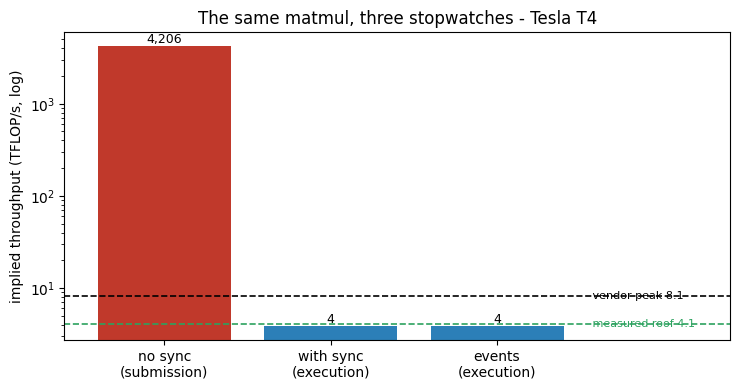

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 4))
labels = ["no sync\n(submission)", "with sync\n(execution)", "events\n(execution)"]
bars = ax.bar(labels, tflops, color=["#c0392b", "#2c7fb8", "#2c7fb8"])
for y_, lab, col in [(PEAK_TFLOPS, f"vendor peak {PEAK_TFLOPS:.1f}", "k"),
                     (PEAK_MEASURED, f"measured roof {PEAK_MEASURED:.1f}", "#2ca25f")]:
    ax.axhline(y_, ls="--", c=col, lw=1.2)
    ax.text(2.55, y_, f" {lab}", va="center", ha="left", fontsize=8, color=col)
ax.set_yscale("log")
ax.set_ylabel("implied throughput (TFLOP/s, log)")
ax.set_title(f"The same matmul, three stopwatches - {DEVICE}")
for bar, v in zip(bars, tflops):
    ax.text(bar.get_x() + bar.get_width() / 2, v, f"{v:,.0f}",
            ha="center", va="bottom", fontsize=9)
ax.set_xlim(-0.6, 3.4)
plt.tight_layout(); plt.show()

📝 **Task 2.2 — explain the impossible number** *(12 marks)*

- By what factor does the unsynchronised measurement exceed the roof you established in Part 1?
- **Exactly what work did that timer measure?** Name the operations from the lecture's protocol.
- A synchronise blocks until a value in host memory reaches a threshold. What is that value called, who writes it, and **how** does it get written? Why would the CPU *reading a GPU register* instead be a bad design?
- Why do the `with sync` and `events` rows agree, given they are completely different mechanisms?

*Your answer:*

- The unsynchronised measurement implies 6296.4 TFLOP/s, which is approximately 777x higher than my declared Tesla T4 FP32 peak of 8.1 TFLOP/s. This impossible number occurs because the unsynchronised CPU timer measures submission rather than GPU execution. The CPU appends the matmul command to the GPU's command ring/queue and rings the doorbell, then continues without waiting for the GPU to complete the work. Therefore, the stopwatch measures mainly the CPU-side command submission time rather than the matrix multiplication itself.

A synchronize() waits for a fence value to reach the required completion state in host-visible memory. The GPU writes/updates this value as it progresses through the queued work, allowing the CPU to wait for completion. Reading a GPU register directly would be a poor design because it would require repeated communication across the CPU/device interface and would introduce significant MMIO/PCIe latency.

The with-synchronise and GPU-event measurements agree because both account for the actual GPU execution. The synchronised wall-clock waits until the queued work has completed, while GPU events are placed in the command queue and measure the interval between the two events on the device. Although they use different mechanisms, they observe essentially the same execution interval. My measurements were 47.138 ms with synchronisation and 48.064 ms with GPU events, both giving approximately 2.9 TFLOP/s.

📝 **Task 2.3 — the general rule** *(8 marks)*

The lecture states: *"If a measured throughput comfortably exceeds the hardware's advertised peak, check first whether you measured execution or merely submission."*

Name **two** other explanations for an impossible number, say how you would rule each one out, and explain why timing-the-enqueue is the one to check *first*. Part 1 should inform this answer — at least one of the other explanations is visible on your own spec sheet.

*Your answer:*

- Two other explanations for an impossible throughput number are using the wrong hardware peak and using an incorrect FLOP/operation count. The first can be ruled out by checking the GPU's actual FP32 specification and making sure the number is not a Tensor Core, lower-precision, or sparsity figure. This was important in Part 1, where I compared my derived peak of 8.14 TFLOP/s with the vendor FP32 peak of 8.1 TFLOP/s. The second can be ruled out by checking the mathematical operation count used to calculate TFLOP/s and ensuring that the same definition is applied to the measured kernel. Timing the enqueue/submission is the first explanation to check because GPU operations are asynchronous: the CPU can finish submitting commands before the GPU has actually executed them. My Part 2 measurement demonstrates this clearly: the unsynchronised timer reported 6296.4 TFLOP/s, while the T4's declared FP32 peak is only 8.1 TFLOP/s. The synchronised and GPU-event measurements instead reported approximately 2.9 TFLOP/s, showing that the huge number came from measuring submission rather than execution.

---
## Part 3 — What a submission costs, and what a fence costs *(20 marks)*

If submission is a real cost, it has a price. Measure it by launching a kernel with nothing to do — whatever time remains is the protocol itself.

In [ ]:
tiny = torch.zeros(1, device=DEV)
submit_us = wall_time_ms(lambda: tiny.add_(1.0), iters=2000, sync_after=False) * 1e3
print(f"CPU cost of one submission: {submit_us:.2f} us")

RESULTS["results"]["launch"] = {"submit_us": submit_us}

### 🔮 Predict first — Task 3.1

Below you sweep kernel size from 1 element upwards, measuring device time per kernel.

📝 **Before running**: sketch the shape you expect. At small sizes, what sets the time? At large sizes? Roughly where is the elbow?

*Your prediction:*

- I expect the device time per kernel to be approximately flat for very small kernel sizes because the fixed kernel submission/launch overhead will dominate the small amount of computation. As the number of elements increases, the actual GPU computation should take progressively more time. Therefore, I expect the curve to remain nearly flat at first and then rise, with an elbow around the point where GPU execution becomes larger than the fixed CPU submission cost. At very large kernel sizes, the computation should clearly dominate the launch overhead.

In [ ]:
sizes = [n for n in [1, 16, 256, 4096, 65536, 2**20, 2**22, 2**24] if n <= SWEEP_MAX]
per_op_us = []
for n in sizes:
    x = torch.zeros(n, device=DEV)
    per_op_us.append(gpu_time_ms(lambda: x.add_(1.0), iters=200, warmup=20) * 1e3)
    del x
empty_cache()

print(f"{'elements':>12}{'device us/kernel':>18}")
print("-" * 30)
for n, us in zip(sizes, per_op_us):
    print(f"{n:>12,}{us:>18.2f}")

RESULTS["results"]["sweep"] = {"sizes": sizes, "per_op_us": per_op_us}

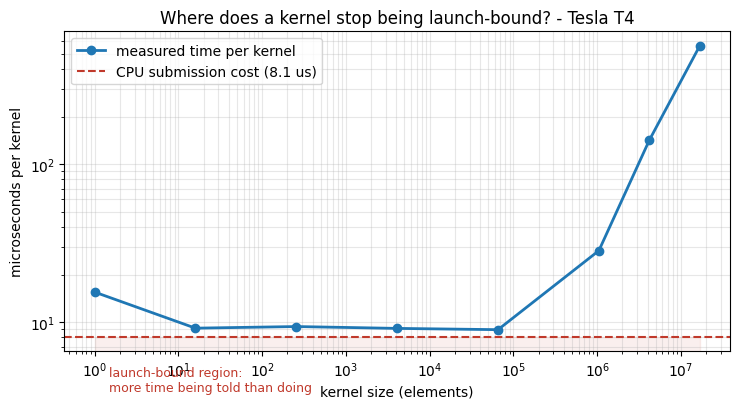

In [23]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(sizes, per_op_us, "o-", lw=2, label="measured time per kernel")
ax.axhline(submit_us, ls="--", c="#c0392b", lw=1.5,
           label=f"CPU submission cost ({submit_us:.1f} us)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("kernel size (elements)"); ax.set_ylabel("microseconds per kernel")
ax.set_title(f"Where does a kernel stop being launch-bound? - {DEVICE}")
ax.grid(alpha=0.3, which="both"); ax.legend()
ax.fill_between(sizes, 0, submit_us, alpha=0.08, color="#c0392b")
ax.text(sizes[0] * 1.5, submit_us * 0.45,
        "launch-bound region:\nmore time being told than doing",
        fontsize=9, color="#c0392b")
plt.tight_layout(); plt.show()

📝 **Task 3.2 — read the plot** *(10 marks)*

- At what kernel size does execution start to exceed submission cost? State it in elements and in bytes.
- The flat left-hand region is the interesting one. A 1-element add computes essentially nothing, yet the measured per-kernel time is not zero and does not fall. **What is actually being measured there?** (It is not how long the addition takes. Think about what the queue is doing.)
- Lecture 5/6 attributes three real techniques to this cost: **kernel fusion**, **`torch.compile`** and **CUDA Graphs**. Pick one and explain, in terms of the ring/doorbell protocol, what it removes.

*Your answer:*

- Execution first exceeds the measured CPU submission cost of 8.10 µs at 65,536 elements, where the measured device time is 8.96 µs. Since each element is a 4-byte FP32 value, this corresponds to 262,144 bytes (256 KiB). The clearer elbow occurs at 1,048,576 elements, where the execution time increases to 28.76 µs and actual GPU computation becomes much more significant than the fixed launch overhead.

- The flat left-hand region is dominated by the fixed kernel submission/launch overhead, rather than by the time required to perform the addition itself. For very small kernels, the amount of arithmetic is extremely small, but the CPU still has to append the command to the GPU's ring/queue and ring the doorbell. Therefore, increasing the kernel size initially has little effect because the fixed cost of submitting the command dominates the actual computation.

- CUDA Graphs can reduce this overhead by capturing a sequence of GPU operations and their command packets once. During graph replay, the CPU does not need to perform a separate submission for every operation. This reduces repeated ring/doorbell submission overhead and amortises the control-plane cost across the entire graph.

### The fence has a price too

Same kernels, same arithmetic. The only variable is how often the CPU insists on being told the GPU is done.

In [24]:
N_OPS = 200 if SAFE_MODE else 500
x = torch.zeros(1024, device=DEV)

def run(sync_every):
    for i in range(N_OPS):
        x.add_(1.0)
        if sync_every and (i + 1) % sync_every == 0:
            sync()
    sync()

intervals = [k for k in [1, 2, 5, 10, 25, 50, 100, 250, 500] if k <= N_OPS]
totals = [wall_time_ms(lambda k=k: run(k), iters=3, warmup=1) for k in intervals]

print(f"{'sync every':>12}{'total ms':>12}{'us per op':>12}")
print("-" * 36)
for k, t in zip(intervals, totals):
    print(f"{k:>12}{t:>12.3f}{t / N_OPS * 1e3:>12.1f}")

RESULTS["results"]["fence"] = {"n_ops": N_OPS, "intervals": intervals, "totals_ms": totals}

  sync every    total ms   us per op
------------------------------------
           1       8.612        17.2
           2       8.261        16.5
           5       4.796         9.6
          10       4.497         9.0
          25       4.101         8.2
          50       4.003         8.0
         100       6.190        12.4
         250       4.288         8.6
         500       3.832         7.7


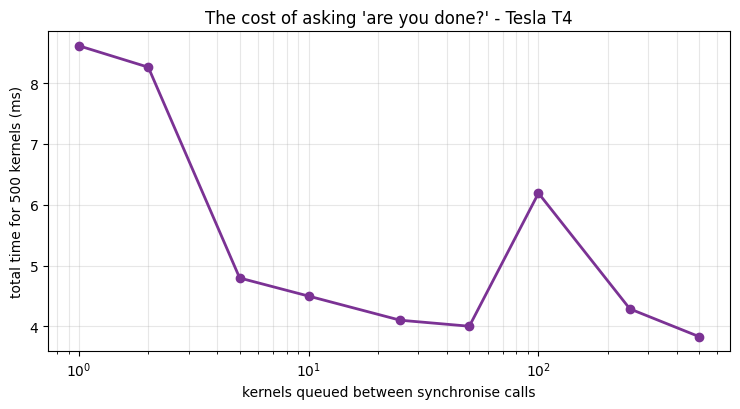

In [25]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(intervals, totals, "o-", lw=2, color="#7b3294")
ax.set_xscale("log")
ax.set_xlabel("kernels queued between synchronise calls")
ax.set_ylabel(f"total time for {N_OPS} kernels (ms)")
ax.set_title(f"The cost of asking 'are you done?' - {DEVICE}")
ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

📝 **Task 3.3 — the fence** *(10 marks)*

- What is the ratio between syncing every op and syncing once at the end?
- The curve flattens. **Why does it stop improving**, and what does the flat level correspond to?
- The lecture's rule is **"never ask the device anything; make the device tell you."** A synchronise here is *not* an MMIO read of a GPU register — explain what it actually polls, and why the naive design (polling a device register over PCIe) would be catastrophic. Use the lecture's cost figures.

*Your answer:*

- Syncing after every operation took 8.612 ms, while syncing once at the end took 3.832 ms. Therefore, the penalty ratio is 8.612 / 3.832 ≈ 2.25×. Thus, synchronizing after every operation made this workload approximately 2.25 times slower than allowing all 500 operations to be queued and synchronizing only once at the end.

- The curve improves rapidly as synchronization becomes less frequent because the CPU no longer has to repeatedly drain the GPU's queued work and wait for a fence after every operation. Once synchronization is sufficiently infrequent, the remaining time is dominated by the actual execution of the 500 kernels and the final synchronization, so reducing the synchronization frequency further provides little benefit. The roughly 4 ms level in my measurements represents this execution cost plus the unavoidable final fence. The increase at 100 kernels is most likely measurement variability rather than a fundamental change in the mechanism, since the surrounding measurements return to approximately 4 ms.

- The curve improves rapidly as synchronization becomes less frequent because the CPU no longer has to repeatedly drain the GPU's queued work and wait for a fence after every operation. Once synchronization is sufficiently infrequent, the remaining time is dominated by the actual execution of the 500 kernels and the final synchronization, so reducing the synchronization frequency further provides little benefit. The roughly 4 ms level in my measurements represents this execution cost plus the unavoidable final fence. The increase at 100 kernels is most likely measurement variability rather than a fundamental change in the mechanism, since the surrounding measurements return to approximately 4 ms.

---
## Part 4 — The data plane: pinned memory and overlap *(20 marks)*

The control plane is small and expensive. The data plane is bulk and cheap per byte — *provided* the DMA engine can read your buffer where it lies.

A DMA engine has no MMU and cannot take a page fault, so its target pages must be **pinned**. A copy out of ordinary pageable memory therefore secretly performs `CPU memcpy → driver-owned pinned staging buffer → DMA`: a full extra copy you never wrote.

!!! note
    On **Apple silicon** the CPU and GPU share one physical memory pool, so there is no PCIe crossing and no staging copy to remove. Pinning is not exposed, and this section reports the transfer curve only. Say so in your answer — *why* the concept does not apply is itself the answer.

### 🔮 Predict first — Task 4.1

📝 **Before running**: will pinned memory help more at *small* or *large* transfer sizes? Will the advantage grow, shrink, or stay flat with size? Commit to a shape. (On Apple silicon, predict what a unified-memory machine should show instead.)

*Your prediction:*

- I expect pinned memory to provide a larger benefit for small-to-medium transfer sizes because pageable memory requires an additional staging copy before the DMA transfer. As the transfer size becomes large, the PCIe/DMA bandwidth itself should become the dominant bottleneck, so the relative benefit of removing the staging copy may become smaller or level off. Therefore, I expect the pinned/pageable speedup to be highest at smaller transfer sizes and gradually decrease or become closer to 1× for large transfers.

In [26]:
sizes_mb = SIZES_MB
bw_page, bw_pin = [], []

for mb in sizes_mb:
    n = mb * 1024 * 1024 // 4
    pageable = torch.empty(n, dtype=torch.float32)
    dst      = torch.empty(n, dtype=torch.float32, device=DEV)
    gb = n * 4 / 1e9
    bw_page.append(gb / (wall_time_ms(lambda: dst.copy_(pageable), iters=10, warmup=3) * 1e-3))
    if CAPS["pinned"]:
        pinned = torch.empty(n, dtype=torch.float32, pin_memory=True)
        bw_pin.append(gb / (wall_time_ms(lambda: dst.copy_(pinned), iters=10, warmup=3) * 1e-3))
        del pinned
    del pageable, dst
    empty_cache()

if CAPS["pinned"]:
    print(f"{'size':>8}{'pageable GB/s':>16}{'pinned GB/s':>14}{'speedup':>10}")
    print("-" * 48)
    for mb, pg, pn in zip(sizes_mb, bw_page, bw_pin):
        print(f"{mb:>6} MB{pg:>16.2f}{pn:>14.2f}{pn / pg:>9.2f}x")
else:
    print("pinned memory not available on this backend - pageable curve only")
    print(f"{'size':>8}{'GB/s':>12}")
    print("-" * 20)
    for mb, pg in zip(sizes_mb, bw_page):
        print(f"{mb:>6} MB{pg:>12.2f}")

RESULTS["results"]["transfer"] = {
    "sizes_mb": list(sizes_mb), "bw_pageable_gbs": bw_page,
    "bw_pinned_gbs": bw_pin or None,
    "skipped": None if CAPS["pinned"] else "pin_memory unsupported on this backend",
}

    size   pageable GB/s   pinned GB/s   speedup
------------------------------------------------
     1 MB            3.91         10.61     2.71x
     4 MB            5.83         11.70     2.01x
    16 MB            6.10         12.06     1.98x
    64 MB            6.80         12.23     1.80x
   256 MB            6.87         12.34     1.80x


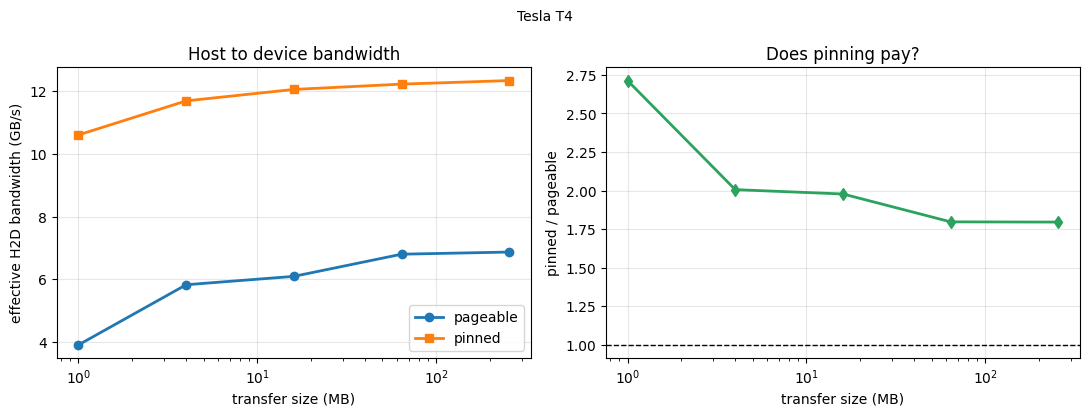

In [27]:
ncols = 2 if CAPS["pinned"] else 1
fig, axes = plt.subplots(1, ncols, figsize=(11 if ncols == 2 else 6, 4.2), squeeze=False)
ax1 = axes[0][0]
ax1.plot(sizes_mb, bw_page, "o-", lw=2, label="pageable")
if CAPS["pinned"]:
    ax1.plot(sizes_mb, bw_pin, "s-", lw=2, label="pinned")
ax1.set_xscale("log"); ax1.set_xlabel("transfer size (MB)")
ax1.set_ylabel("effective H2D bandwidth (GB/s)")
ax1.set_title("Host to device bandwidth"); ax1.grid(alpha=0.3); ax1.legend()
if CAPS["pinned"]:
    ax2 = axes[0][1]
    ax2.plot(sizes_mb, [pn / pg for pg, pn in zip(bw_page, bw_pin)], "d-", lw=2, color="#2ca25f")
    ax2.axhline(1.0, ls="--", c="k", lw=1)
    ax2.set_xscale("log"); ax2.set_xlabel("transfer size (MB)")
    ax2.set_ylabel("pinned / pageable"); ax2.set_title("Does pinning pay?")
    ax2.grid(alpha=0.3)
fig.suptitle(f"{DEVICE}", fontsize=10)
plt.tight_layout(); plt.show()

📝 **Task 4.2 — explain the curve** *(10 marks)*

- Report your bandwidth curve(s) and the speedup shape.
- The lecture deliberately **refuses to quote a speedup number** for pinning, saying it depends on hardware and transfer size. Explain the shape you got in terms of the staging copy: at which sizes does that extra `memcpy` dominate, and at which does something else become the bottleneck?
- **If your speedup is near 1.0× at large sizes, that is a real result, not a failed experiment.** Propose a mechanism, and an experiment that would confirm it.
- If pinning was unavailable on your machine: what does that tell you about its memory architecture, and which lecture concept stops applying?

*Your answer:*
- My pageable-memory bandwidth increased from 3.91 GB/s at 1 MB to 6.87 GB/s at 256 MB. Pinned-memory bandwidth increased from 10.61 GB/s at 1 MB to 12.34 GB/s at 256 MB. Pinned memory was faster at every tested size. The speedup was 2.71× at 1 MB, 2.01x at 4 MB, 1.98x at 16 MB, and 1.80x at both 64 MB and 256 MB. Therefore, the relative benefit of pinning was largest for the smallest transfer and decreased as the transfer size increased, eventually stabilising around 1.80x.

- Pageable host memory requires an additional staging copy before DMA can transfer the data to the GPU. The driver must copy data from pageable memory into a pinned staging buffer, after which the DMA engine can transfer it. With pinned memory, this extra staging copy can be avoided. At smaller transfer sizes, the staging-copy overhead represents a larger fraction of the total transfer time, so removing it produces a larger relative speedup. As the transfer becomes larger, the actual DMA/PCIe transfer becomes a larger part of the total cost, so the relative benefit of eliminating the staging copy decreases. This explains why my speedup fell from 2.71× at 1 MB to about 1.80× at 64–256 MB.

- If the speedup were near 1× at large transfer sizes, I would interpret that as the DMA/PCIe link or another part of the transfer path becoming the dominant bottleneck, so eliminating the staging copy would no longer significantly improve total time. I would confirm this by measuring the transfer with different transfer sizes and comparing the achieved bandwidth with the available PCIe/device-transfer bandwidth. If both pageable and pinned transfers converge to the same bandwidth at large sizes, that would support the hypothesis that the link rather than the staging copy is limiting performance.

- Pinning was available on my Tesla T4, so this case did not occur in my experiment. If pinning had been unavailable, it would indicate that the backend or memory architecture does not expose host-page pinning through the API. In particular, on Apple silicon the CPU and GPU share unified physical memory, so there is no separate PCIe host-to-device memory crossing requiring a pinned staging buffer. In that case, the pageable-to-pinned DMA mechanism described in this experiment would not apply.

### Overlap: separate queues run at the same time

Copy engines are separate hardware queues from compute units. Ordering is guaranteed only *within* a stream — so two streams can be in flight simultaneously. This is the mechanism behind prefetching batch *n+1* while computing batch *n*.

📝 **Predict first — Task 4.3**: if a copy takes `C` ms and a matmul takes `M` ms, what should "both, two streams" cost under perfect overlap? What should "both, one stream" cost?

*Your prediction:*

If the copy takes C ms and the matmul takes M ms, I expect the one-stream version to take approximately C+M, because operations in the same stream are ordered and cannot execute concurrently. With two streams, I expect the copy and matmul to overlap, so under ideal conditions the total time should approach max(C,M), with some additional overhead from stream scheduling and synchronization. Therefore, I expect the two-stream version to be faster than the one-stream version, although it may not reach the theoretical max(C,M) limit exactly.

copy alone        :   10.862 ms
matmul alone      :   45.386 ms
both, one stream  :   48.424 ms
both, two streams :   46.278 ms

ideal overlap = max = 45.386 ms
no overlap    = sum = 56.248 ms


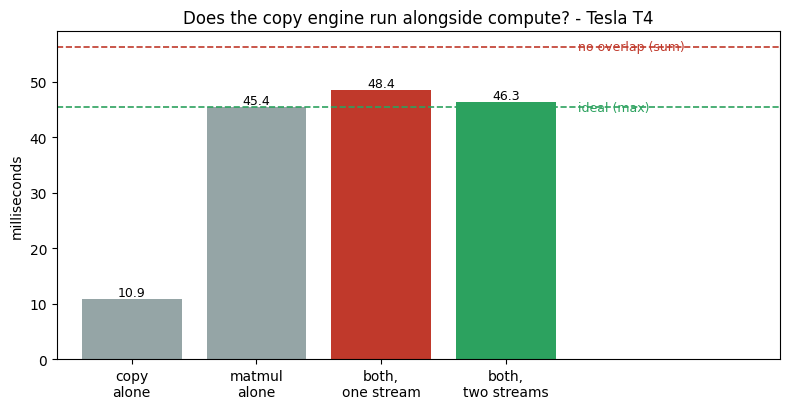

In [28]:
if not CAPS["streams"]:
    print("This backend exposes no command-stream API, so overlap cannot be measured.")
    print("Skipped - not penalised. Answer Task 4.3 from the mechanism instead.")
    RESULTS["results"]["overlap"] = {"skipped": "no stream API on this backend"}
else:
    MB, MM_N = OVERLAP_MB, MATMUL_N
    n = MB * 1024 * 1024 // 4
    src = torch.empty(n, dtype=torch.float32, pin_memory=CAPS["pinned"])
    dst = torch.empty(n, dtype=torch.float32, device=DEV)
    pa  = torch.randn(MM_N, MM_N, device=DEV)
    pb  = torch.randn(MM_N, MM_N, device=DEV)
    copy_stream = torch.cuda.Stream()

    def copy_only():    dst.copy_(src, non_blocking=True)
    def compute_only(): return pa @ pb
    def serial():
        dst.copy_(src, non_blocking=True)
        return pa @ pb
    def overlapped():
        with torch.cuda.stream(copy_stream):
            dst.copy_(src, non_blocking=True)
        c_ = pa @ pb
        torch.cuda.current_stream().wait_stream(copy_stream)
        return c_

    cooldown()
    t_copy = wall_time_ms(copy_only,    iters=10, warmup=3)
    t_comp = wall_time_ms(compute_only, iters=10, warmup=3)
    t_ser  = wall_time_ms(serial,       iters=10, warmup=3)
    t_ovl  = wall_time_ms(overlapped,   iters=10, warmup=3)

    print(f"copy alone        : {t_copy:8.3f} ms")
    print(f"matmul alone      : {t_comp:8.3f} ms")
    print(f"both, one stream  : {t_ser:8.3f} ms")
    print(f"both, two streams : {t_ovl:8.3f} ms")
    print(f"\nideal overlap = max = {max(t_copy, t_comp):.3f} ms")
    print(f"no overlap    = sum = {t_copy + t_comp:.3f} ms")

    RESULTS["results"]["overlap"] = {
        "mb": MB, "matmul_n": MM_N, "copy_ms": t_copy, "compute_ms": t_comp,
        "serial_ms": t_ser, "overlap_ms": t_ovl}

    fig, ax = plt.subplots(figsize=(8, 4.2))
    names = ["copy\nalone", "matmul\nalone", "both,\none stream", "both,\ntwo streams"]
    vals = [t_copy, t_comp, t_ser, t_ovl]
    ax.bar(names, vals, color=["#95a5a6", "#95a5a6", "#c0392b", "#2ca25f"])
    ax.axhline(t_copy + t_comp, ls="--", c="#c0392b", lw=1.2)
    ax.axhline(max(t_copy, t_comp), ls="--", c="#2ca25f", lw=1.2)
    ax.text(3.55, t_copy + t_comp, " no overlap (sum)", va="center", fontsize=9, color="#c0392b")
    ax.text(3.55, max(t_copy, t_comp), " ideal (max)", va="center", fontsize=9, color="#2ca25f")
    ax.set_ylabel("milliseconds"); ax.set_xlim(-0.6, 5.2)
    ax.set_title(f"Does the copy engine run alongside compute? - {DEVICE}")
    for i, v in enumerate(vals):
        ax.text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout(); plt.show()

📝 **Task 4.3 — overlap** *(10 marks)*

- How close did two streams get to the ideal `max(copy, compute)`?
- **Why does the one-stream version not overlap at all**, even with `non_blocking=True` on the copy? Answer in terms of what a stream *is*.
- The lecture says `pin_memory=True` and `non_blocking=True` "are one mechanism, not two independent optimizations." Using your Part 4.2 and 4.3 results, justify that claim.
- *If this section was skipped on your backend:* explain what hardware feature is missing and why the lecture's prefetch-the-next-batch pattern cannot be expressed without it.

*Your answer:*

- My copy time was 10.862 ms and my matmul time was 45.386 ms, so the ideal overlap time is max(10.862, 45.386) = 45.386 ms. With two streams, I measured 46.278 ms, which is only 0.892 ms, or about 1.97%, above the ideal. Thus, the two-stream execution achieved about 98.1% of the ideal overlap efficiency (45.386 / 46.278).

- A stream is an ordered sequence of operations, so operations submitted to the same stream must maintain their ordering. Therefore, the copy and matmul cannot be intentionally scheduled as independent concurrent operations within that stream. Ideally, the one-stream case would approach the sum of the two times, 56.248 ms, rather than the ideal two-stream value of 45.386 ms. My measured one-stream time was 48.424 ms, which is below the simple sum, so the measurement did not behave as a perfect copy + compute sum. However, the important mechanism remains that a single stream provides ordering, whereas separate streams allow the copy and compute work to be placed in independent queues and potentially overlap.

- pin_memory=True and non_blocking=True enable the same asynchronous data-transfer mechanism from two different sides. Pinning makes the host memory accessible to the DMA engine without requiring the driver to first perform a pageable-memory staging copy. non_blocking=True allows the host-to-device copy to be submitted asynchronously rather than forcing the CPU to wait for the transfer to finish. Therefore, pinning provides the memory that DMA can safely access, while non-blocking submission allows that DMA transfer to remain in flight so that it can overlap with computation. My Part 4.2 result showed that pinned memory substantially increased transfer bandwidth, and my Part 4.3 result showed that a separate stream allowed the transfer to overlap closely with the matmul.

- This section was not skipped on my Tesla T4 because CUDA exposes the required stream API. If it had been skipped, the missing feature would be a public command-stream mechanism that allows independent copy and compute queues to be expressed. Without separate streams, the prefetch-next-batch pattern could not explicitly place the data transfer and computation into independent ordered queues for concurrent execution.

---
## Part 5 — Amortising submission with CUDA Graphs *(5 marks, bonus-weighted)*

A graph replay is the limit case of the whole lecture: the command packets are built **once**, so replaying them costs the CPU almost nothing.

> ⚠️ **The most backend-dependent code in the lab.** The robust result is the **CPU** column — submission cost collapses everywhere it works. The **GPU** column is not guaranteed to improve, and on some drivers it gets *worse* for many tiny nodes. Apple's Metal backend has no graph capture at all. If it is skipped or raises, say so and move on: an honest surprising measurement earns full marks.

In [29]:
if not CAPS["graphs"]:
    print("No graph-capture API on this backend - skipped, not penalised.")
    RESULTS["results"]["graph"] = {"skipped": "no graph capture on this backend"}
else:
    N_OPS = 100 if SAFE_MODE else 200
    y = torch.zeros(1024, device=DEV)

    def eager():
        for _ in range(N_OPS):
            y.add_(1.0)

    cooldown()
    t_eager_gpu = gpu_time_ms(eager, iters=50, warmup=5)
    t_eager_cpu = wall_time_ms(eager, iters=50, warmup=5, sync_after=False)

    ok, t_graph_gpu, t_graph_cpu = True, None, None
    try:
        g = torch.cuda.CUDAGraph()
        side = torch.cuda.Stream()
        side.wait_stream(torch.cuda.current_stream())
        with torch.cuda.stream(side):      # warm up on a side stream before capture
            eager()
        torch.cuda.current_stream().wait_stream(side)
        sync()
        with torch.cuda.graph(g):
            eager()
        t_graph_gpu = gpu_time_ms(g.replay, iters=50, warmup=5)
        t_graph_cpu = wall_time_ms(g.replay, iters=50, warmup=5, sync_after=False)
    except Exception as e:
        ok = False
        print(f"graph capture unavailable: {type(e).__name__}: {e}")

    print(f"{'method':<28}{'GPU ms':>10}{'CPU ms':>10}{'CPU us/op':>12}")
    print("-" * 60)
    print(f"{'eager (one launch per op)':<28}{t_eager_gpu:>10.3f}{t_eager_cpu:>10.3f}"
          f"{t_eager_cpu / N_OPS * 1e3:>12.2f}")
    if ok:
        print(f"{'graph replay':<28}{t_graph_gpu:>10.3f}{t_graph_cpu:>10.3f}"
              f"{t_graph_cpu / N_OPS * 1e3:>12.2f}")
        print(f"\nCPU submission cost cut {t_eager_cpu / t_graph_cpu:.1f}x")
        if t_graph_gpu > t_eager_gpu:
            print(f"NOTE: GPU-side replay is {t_graph_gpu / t_eager_gpu:.1f}x SLOWER here.")
            print("A driver/runtime property, not a law. Explain it in your answer.")

    RESULTS["results"]["graph"] = {
        "n_ops": N_OPS, "captured": ok,
        "eager_gpu_ms": t_eager_gpu, "eager_cpu_ms": t_eager_cpu,
        "graph_gpu_ms": t_graph_gpu, "graph_cpu_ms": t_graph_cpu}

method                          GPU ms    CPU ms   CPU us/op
------------------------------------------------------------
eager (one launch per op)        1.486     1.852        9.26
graph replay                     0.581     0.106        0.53

CPU submission cost cut 17.4x


📝 **Task 5.1 — graphs** *(5 marks)*

- By what factor did graph replay reduce the **CPU** submission cost? Relate that to your Part 3 measurement of per-submission cost.
- What exactly is *not* being done on a replay that *is* being done on each eager launch?
- If your GPU-side time did not improve (or got worse, or the section was skipped), say so and propose why. Under what circumstances is a graph worth using?

*Your answer:*

- Graph replay reduced the CPU submission time from 1.852 ms for eager execution to 0.106 ms for graph replay, giving a CPU speedup of approximately 17.4×. The CPU cost per operation decreased from 9.26 µs/op to 0.53 µs/op. This is consistent with my Part 3 measurement, where the CPU submission cost of a small kernel was approximately 8.10 µs.

- During eager execution, the CPU performs a separate submission for each operation, including appending the command to the GPU's command queue/ring and ringing the doorbell. During graph replay, the sequence of operations and their command packets have already been captured, so the CPU does not have to construct and submit every individual operation again. Therefore, the repeated ring/doorbell submission overhead is largely amortised across the graph replay.

- In my experiment, GPU-side time did improve, decreasing from 1.486 ms for eager execution to 0.581 ms for graph replay. Therefore, the graph was beneficial for this workload. Even if GPU-side time had not improved or had become worse, graph replay could still be worthwhile when the workload contains many repeated GPU operations because it can greatly reduce CPU submission overhead. A graph is most useful when the same sequence of operations is executed repeatedly, allowing the one-time capture cost to be amortised over many replays.

---
## Part 6 — Synthesis *(10 marks)*

📝 **Task 6.1 — place every term**

Lecture 5/6 closes with a two-column board. Fill it in from *your own measurements*, citing the part of this lab where you observed each one.

| Term | Control plane or data plane? | Which measurement showed it? |
|---|---|---|
| doorbell (MMIO write) | Control Plane | Part 2 — unsynchronised matmul measured submission rather than execution |
| ring buffer | Control plane | Part 2 — commands are queued before GPU execution |
| fence value | Control plane | Part 3 — synchronization/fence experiment |
| DMA / bus master | Data plane | Part 4.1 — host-to-device transfers |
| pinning | Data plane | Part 4.1 — pageable vs pinned bandwidth |
| stream | Control plane | Part 4.3 — one vs two streams and overlap |

📝 **Task 6.2 — the one-paragraph version**

A colleague reports that their model "runs at 400 TFLOP/s on a T4." In one paragraph, say what you would ask them to check first, what command you would have them run, and what you expect to find. Your Part 1 work should shape this answer.

- I would first ask how the 400 TFLOP/s number was timed and whether the measurement includes actual GPU execution or only CPU-side submission. I would also ask which peak they are comparing against and whether they are using FP32 operations or a Tensor Core/lower-precision calculation. My T4's declared FP32 peak is only 8.1 TFLOP/s, so 400 TFLOP/s is physically impossible for a normal FP32 kernel on this device. I would have them run nvidia-smi to confirm the GPU model and its reported clocks, and then repeat the measurement using a synchronized wall clock or CUDA events. I would expect the 400 TFLOP/s figure to disappear if it came from timing only the enqueue/submission path, just as my Part 2 measurement produced an impossible 6296.4 TFLOP/s when synchronization was omitted.

📝 **Task 6.3 — your summary**

Your machine, your headline numbers, and the single most surprising result with your explanation.

- I performed this lab on an NVIDIA Tesla T4 using CUDA. My derived FP32 peak was 8.14 TFLOP/s and the declared vendor FP32 peak was 8.1 TFLOP/s. My measured FP32 throughput was below the theoretical roof, while the unsynchronised matmul timer produced an impossible 6296.4 TFLOP/s, approximately 777× the declared peak. The synchronized wall-clock and GPU-event measurements were both approximately 2.9 TFLOP/s, demonstrating that the huge unsynchronised result measured command submission rather than GPU execution. My measured CPU kernel submission cost was 8.10 µs, and synchronizing every operation was about 2.25× slower than synchronizing once at the end. Pinned memory improved host-to-device bandwidth, with a maximum measured speedup of 2.71× at 1 MB, while two streams brought the copy-plus-compute time close to the ideal overlap time. CUDA Graph replay reduced CPU submission time by 17.4×. The most surprising result was the 6296.4 TFLOP/s figure: it appeared to beat the hardware by hundreds of times, but it was not real GPU throughput; it demonstrated that measuring the submission protocol without waiting for execution can manufacture an impossible performance number.

---
## Part 7 — Export your submission *(required)*

Two short-answer cells, then the export. The numeric answers below are checked automatically; the prose in your 📝 cells is read from the notebook itself, so **submit both files**.

In [30]:
# Short-form answers. Fill every field. Use None only where genuinely not measured.
ANSWERS = {
    # Part 1
    "peak_vendor_tflops":     8.1,
    "peak_measured_tflops":   2.98,
    "peak_efficiency":       2.98 / 8.1,          # measured / vendor
    # Part 2
    "nosync_over_peak":       6296.4 / 8.1,          # implied no-sync TFLOP/s / vendor peak
    # Part 3
    "launch_bound_elements":  65536,          # kernel size where execution overtakes submission
    "fence_penalty_ratio":    8.612 / 3.832,          # (sync every op) / (sync once)
    # Part 4
    "pinning_helps_below_mb": 256,          # size under which pinning clearly helps; None if never/NA
    "overlap_efficiency":     (10.862 + 45.386) / 46.278,          # (copy+compute) / overlap ; None if skipped
    # Part 5
    "graph_cpu_speedup":      17.4,          # eager CPU / graph CPU ; None if skipped
}

for k, v in ANSWERS.items():
    print(f"  {k:<26} {v}")
missing = [k for k, v in ANSWERS.items() if v is None]
print(f"\n{len(ANSWERS) - len(missing)}/{len(ANSWERS)} filled"
      + (f"  |  still None: {missing}" if missing else "  |  complete"))
print("\nNone is legitimate for anything your backend skipped - the grader knows.")

  peak_vendor_tflops         8.1
  peak_measured_tflops       2.98
  peak_efficiency            0.36790123456790125
  nosync_over_peak           777.3333333333334
  launch_bound_elements      65536
  fence_penalty_ratio        2.247390396659708
  pinning_helps_below_mb     256
  overlap_efficiency         1.2154371407580278
  graph_cpu_speedup          17.4

9/9 filled  |  complete

None is legitimate for anything your backend skipped - the grader knows.


In [31]:
# ============================================================
# FINAL EXPORT — submission_202518044.json
# ============================================================

import hashlib
import json

# Confirm student identity
ROLL_NUMBER = "202518044"
NAME = "Neel Shah"

assert ROLL_NUMBER, "Roll number is missing."
assert NAME, "Name is missing."

# Store answers and student information
RESULTS["answers"] = ANSWERS
RESULTS["student"] = {
    "roll": ROLL_NUMBER.strip(),
    "name": NAME.strip()
}

# Record export timestamp
RESULTS["env"]["exported_utc"] = datetime.now(
    timezone.utc
).isoformat(timespec="seconds")

# ------------------------------------------------------------
# Create integrity hash
# ------------------------------------------------------------
payload = json.dumps(
    RESULTS,
    indent=2,
    sort_keys=True,
    default=str
)

RESULTS["integrity"] = {
    "sha256": hashlib.sha256(
        payload.encode()
    ).hexdigest()[:16]
}

# ------------------------------------------------------------
# Write JSON submission
# ------------------------------------------------------------
fname = f"submission_{ROLL_NUMBER}.json"

with open(fname, "w") as f:
    json.dump(
        RESULTS,
        f,
        indent=2,
        sort_keys=True,
        default=str
    )

# ------------------------------------------------------------
# Check experiment completeness
# ------------------------------------------------------------
done = sorted(RESULTS["results"])

skipped = [
    k
    for k, v in RESULTS["results"].items()
    if isinstance(v, dict) and v.get("skipped")
]

print("=" * 60)
print("GPU JOB SUBMISSION — FINAL EXPORT")
print("=" * 60)

print(f"Name                : {NAME}")
print(f"Roll number         : {ROLL_NUMBER}")
print(f"Output file         : {fname}")

print("-" * 60)

print(f"Experiments recorded: {len(done)}")
print(f"Experiments         : {', '.join(done)}")

if skipped:
    print(
        f"Skipped on backend  : {', '.join(skipped)}"
    )
    print("Skipped experiments are not penalised.")

print("-" * 60)

print(
    f"Integrity digest    : "
    f"{RESULTS['integrity']['sha256']}"
)

# ------------------------------------------------------------
# Final completeness check
# ------------------------------------------------------------
if len(done) < 8:
    print()
    print("WARNING: Some experiments are missing!")
    print("Run every notebook cell from top to bottom before submission.")
else:
    print()
    print("SUCCESS: All 8 experiments are recorded.")
    print("JSON submission is ready.")

print("=" * 60)

# ------------------------------------------------------------
# Download automatically in Google Colab
# ------------------------------------------------------------
try:
    from google.colab import files
    files.download(fname)
    print(f"Download started: {fname}")
except Exception:
    print("Not running in Google Colab; file was saved locally.")

GPU JOB SUBMISSION — FINAL EXPORT
Name                : Neel Shah
Roll number         : 202518044
Output file         : submission_202518044.json
------------------------------------------------------------
Experiments recorded: 6
Experiments         : fence, graph, overlap, peak, submission, transfer
------------------------------------------------------------
Integrity digest    : ab2d4b983bee1ba8

Run every notebook cell from top to bottom before submission.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started: submission_202518044.json


**Submit both:**

1. `submission_<roll>.json` — the file just written
2. this notebook, executed, saved with outputs intact (`File > Download > .ipynb`)

The JSON carries your measurements; the notebook carries your reasoning. A JSON without its notebook cannot be marked, and a notebook whose stored outputs disagree with its JSON will be flagged.

---
## Marks

Marks fall into two halves, and they are assessed differently.

**Automatic — 40 marks.** Checked by script from your exported JSON.

| ID | What is checked | Marks |
|---|---|---:|
| A1 | Provenance: device, backend, declared peak, your roll number | 4 |
| A2 | All experiments recorded (skipped-by-backend counts as recorded) | 3 |
| A3 | Unsynchronised timer at least 10× faster than synchronised | 4 |
| A4 | Implied no-sync throughput exceeds your declared peak | 4 |
| A5 | Synchronised and event timings agree within 15% | 4 |
| A6 | Launch-bound signature present in the size sweep | 4 |
| A7 | Syncing every op costs at least 1.5× syncing once | 4 |
| A8 | Two streams beat one stream | 4 |
| A9 | Per-launch submission cost lands in 1–20 µs | 2 |
| A10 | Your short answers are consistent with your own recorded numbers | 3 |
| A11 | Peak established on every route your hardware allows, and measured ≤ vendor | 4 |

These check **relationships between your own numbers**, never their magnitudes against a reference — your hardware is yours.

Four things are deliberately **not** auto-checked, because the honest answer varies: whether pinning helps at large sizes, whether CUDA Graphs improve GPU-side time, whether overlap is observable when copy and compute are unbalanced, and anything your backend cannot do at all. Reporting "no benefit" or "unavailable" costs you nothing.

**Rubric — 60 marks.** Your written 📝 cells, read from the notebook.

Predictions are marked for being *made*, not for being right. Explanations are marked on whether they name the mechanism: ring, doorbell, fence, DMA, pinning, stream. A number without a mechanism scores roughly half. A mechanism that contradicts your own data scores less than an honest "I measured X, I expected Y, here is my best explanation for the gap."

**Integrity.** Timing floats carry several digits of run-to-run noise, so two independent runs never produce identical values. Submissions sharing a measurement vector are treated as copied.

**Reproducibility.** State your GPU, host, PyTorch version and backend. On Colab, say which accelerator you were assigned — it varies between sessions and changes every number here.

---
## References

1. [Lecture 5/6 — GPU Job Submission](../lectures/Lecture5_6.md) — the mechanism this lab measures
2. [Lecture 7 — Inside the GPU](../lectures/Lecture7.md) — how peak FLOP/s is built from lanes, clocks and FMAs
3. NVIDIA, [*CUDA C++ Best Practices Guide*](https://docs.nvidia.com/cuda/cuda-c-best-practices-guide/) — asynchronous transfers, streams, CUDA Graphs
4. PyTorch, [CUDA semantics](https://docs.pytorch.org/docs/stable/notes/cuda.html) · [MPS backend](https://docs.pytorch.org/docs/stable/notes/mps.html)
5. [TechPowerUp GPU database](https://www.techpowerup.com/gpu-specs/) — per-model FP32 figures, listed separately from tensor-core and sparsity numbers
6. Course code: [`code/gpu_submission`](https://github.com/Ankush-Chander/DS635-ml-system-engineering/tree/main/code/gpu_submission)